<a href="https://colab.research.google.com/github/JingwenLuo7/MLAILS-2026/blob/main/Project_1_Jingwen_Luo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objectives

- Collect data and code from paper source: https://link.springer.com/article/10.1007/s11306-019-1612-4
  - Data: https://github.com/CIMCB/MetabComparisonBinaryML/blob/master/notebooks/data/MTBLS90.xlsx
  - Code source:
    - https://github.com/CIMCB/MetabComparisonBinaryML/blob/master/notebooks/SVMRBF_MTBLS90.ipynb
    - https://github.com/CIMCB/MetabComparisonBinaryML/blob/master/notebooks/PCLR_MTBLS90.ipynb
    - https://github.com/CIMCB/MetabComparisonBinaryML/blob/master/notebooks/ANNLinSig_MTBLS90.ipynb
    - https://github.com/CIMCB/MetabComparisonBinaryML/blob/master/notebooks/ANNSigSig_MTBLS90.ipynb

- Perform ML analysis on real data

  - Redo the analysis as in the paper, without the cimcb package.
    
    - use scikit-learn package: https://scikit-learn.org/stable/supervised_learning.html

  - Redo the analysis on selected dataset: **MTBLS90**
    - Understand the data structure.
    - Preprocess the data with Tidy Data framework
    - Deal with Missing values

  - Understand several Machine Learning (ML) algorithms
    - Understand how to do hyperparameter optimization
      - https://medium.com/@chanakapinfo/hyperparameter-tuning-explained-manual-tuning-gridsearchcv-and-randomizedsearchcv-bf0308162ebb
    - For three of the resulting models (binary classifiers), extract the n=3 most important features, i.e. metabolites.

- Compare ML results in a systematic way


# Environment settings

## 0.1 Install packages

In [ ]:
!pip install matplotlib
!pip install pandas
!pip install scikit-learn

## 0.2 Load pakages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Data preprocessing

## 1.1 Data loading

In [ ]:
### Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


This is a plasma LC-MS dataset consisting of 189 named metabolites. This was a large prospective epidemiological study of men and women at age 70 living in Uppsala, Sweden. For the purpose of this study, males (Class=1; n=485) and females (Class=0; n=483) in a binary discriminant analysis were compared.

In [ ]:
# !ls /content/drive/MyDrive/MLAILS-2026/Project_1/
file_path = '/content/drive/MyDrive/MLAILS-2026/Project_1/data/MTBLS90.xlsx'

df_data = pd.read_excel(file_path, sheet_name='Data')
df_peak = pd.read_excel(file_path, sheet_name='Peak')

# Display the first 5 rows of the DataFrame to confirm it's loaded correctly
display(df_data.head())

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Idx,SampleID,Class,Sex,M1,M2,M3,M4,M5,M6,...,M180,M181,M182,M183,M184,M185,M186,M187,M188,M189
0,1,subject_1524,0,Female,14.98474,14.49947,12.097435,12.043818,11.436392,16.07217,...,20.70097,20.19814,21.28179,21.09176,16.46404,12.269896,17.29323,19.81546,19.35259,12.71608
1,2,subject_1525,1,Male,15.17667,14.50172,12.363773,12.240458,11.577436,14.93265,...,21.68605,20.51608,21.25777,20.53935,16.33413,12.031267,18.08144,19.96693,19.50694,13.20891
2,3,subject_1527,1,Male,15.35934,14.41941,12.510494,11.234959,11.199970,15.22600,...,20.46320,20.34297,21.34793,20.81883,16.44281,12.679043,17.24765,20.01505,20.34058,12.98210
3,4,subject_1528,1,Male,15.12638,14.75630,13.001426,12.640496,11.244146,14.78994,...,21.36879,20.93957,21.09719,20.82021,16.27483,12.323163,17.72392,19.57522,19.18157,12.41039
4,5,subject_1529,1,Male,15.20272,14.48083,12.392280,10.779516,10.968423,15.75598,...,20.80482,19.82493,20.84250,20.31349,16.33279,12.352881,17.59348,19.88594,18.66284,12.37479


In [ ]:
print(df_data.shape)
print(df_peak.shape)

(968, 193)
(189, 3)


In [ ]:
df_peak

,Idx,Name,Label
0,1,M1,Choline
1,2,M2,Creatinine
2,3,M3,e-Caprolactam
3,4,M4,DL-2-Aminooctanoic acid
4,5,M5,Gamma-Caprolactone
...,...,...,...
184,185,M185,N-(15Z-tetracosenoyl)-sphinganine-1-phosphocho...
185,186,M186,Phosphatidylcholine(40:6)
186,187,M187,Sphingomyelin(42:3)
187,188,M188,Phosphatidylcholine(40:5)


## 1.2 Train/Test split

In [ ]:
PeakList = df_peak['Name'].tolist()

# Select Subset of Data
df_data = df_data[(df_data.Class == 1) | (df_data.Class == 0)]

# Create a Binary Y Vector
Outcomes = df_data['Class']
Y = Outcomes.values

# Split Data into Train (2/3) and Test (1/3)
# The stratify=y parameter in train_test_split ensures that the proportion of classes in the training and testing sets is the same as the proportion of classes in the original dataset y.
DataTrain, DataTest, YTrain, YTest = train_test_split(df_data, Y, test_size=1/3, stratify=Y, random_state=8)

# Check for missing values initially
print("Missing values in X_train before preprocessing:")
display(DataTrain.isnull().sum().sum())
print("Missing values in X_test before preprocessing:")
display(DataTest.isnull().sum().sum())


print("Missing values in Y_TRain before preprocessing:")
display(np.isnan(YTrain).sum())
print("Missing values in Y_Test before preprocessing:")
display(np.isnan(YTest).sum())

Missing values in X_train before preprocessing:


np.int64(0)

Missing values in X_test before preprocessing:


np.int64(0)

Missing values in Y_TRain before preprocessing:


np.int64(0)

Missing values in Y_Test before preprocessing:


np.int64(0)

In [38]:
# Count cases for each class in Train and Test sets
train_counts = pd.Series(YTrain).value_counts().sort_index()
test_counts = pd.Series(YTest).value_counts().sort_index()

# Create a summary table
case_summary = pd.DataFrame({
    'Class 0 (Female)': [train_counts[0], test_counts[0], train_counts[0] + test_counts[0]],
    'Class 1 (Male)': [train_counts[1], test_counts[1], train_counts[1] + test_counts[1]],
    'Total': [len(YTrain), len(YTest), len(YTrain) + len(YTest)]
}, index=['Train', 'Test', 'Total'])

display(case_summary)

,Class 0 (Female),Class 1 (Male),Total
Train,322,323,645
Test,161,162,323
Total,483,485,968


## 1.3 Missing values

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

# Extract Train Data
XTrain = DataTrain[PeakList]
XTest = DataTest[PeakList]

# Apply Log Transformation
# Apply a logarithm (natural log, np.log in this case) compresses the larger values and spreads out the smaller values,
# making the distribution more symmetrical and closer to a normal distribution.
# This helps reduce the impact of outliers and stabilizes the variance, which can improve model performance.
XTrainLog = np.log(XTrain.replace(0, np.nan).fillna(XTrain.min().min()/2))
XTestLog = np.log(XTest.replace(0, np.nan).fillna(XTest.min().min()/2))


# Initialize StandardScaler
scaler = StandardScaler()

# Fit on X_train_log and transform both X_train_log and X_test_log
X_train_scaled = scaler.fit_transform(XTrainLog)
X_test_scaled = scaler.transform(XTestLog)
# fit() part: call fit() on the training data (XTrainLog), the StandardScaler learns the parameters it needs for scaling.
# Specifically, it calculates the mean (μ) and standard deviation (σ) for each feature (column) in XTrainLog dataset.
# It's crucial to learn these parameters only from the training data to prevent data leakage from the test set.

# transform() part: After learning the means and standard deviations, it then applies the scaling transformation to the XTrainLog data.
# For each feature, it subtracts the learned mean and divides by the learned standard deviation: (x - μ) / σ.
# This results in X_train_scaled, where each feature has a mean of approximately 0 and a standard deviation of 1.

# Convert scaled arrays back to DataFrames for easier imputation and feature naming
X_train_scaled = pd.DataFrame(X_train_scaled, columns=XTrain.columns, index=XTrain.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=XTest.columns, index=XTest.index)

# Initialize KNNImputer
imputer = KNNImputer(n_neighbors=3)

# Fit on X_train_scaled and transform both X_train_scaled and X_test_scaled
X_train_knn = imputer.fit_transform(X_train_scaled)
X_test_knn = imputer.transform(X_test_scaled)

print(f"X_train shape after preprocessing: {X_train_knn.shape}")
print(f"X_test shape after preprocessing: {X_test_knn.shape}")


X_train shape after preprocessing: (645, 189)
X_test shape after preprocessing: (323, 189)


# ML Analysis

- https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

- https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression

- https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

## 2.1 Hyperparameter optimization

### 2.1.1 SVM-RBF
SVM uses the following Hyperparameter(s):

- kernel: specifies the type of kernel. For SVM-RBF, this needs to be set to 'rbf'.
- C: the cost parameter that determines how soft or hard (i.e. strict) the hyperplane margin is (default=1)
- gamma: the parameter that (intuitively) sets the influence a single sample has on the model (default=1/n_features)

The purpose of each hyperparameter is explained here: Hsu et al. (2003)

In [ ]:
# Define the SVM model
svm_model = SVC(probability=True, random_state=8)

# Define the parameter grid for GridSearchCV
param_grid = {
    'kernel': ['rbf'],
    'C': [1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9],

    'gamma': [1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
}

# Initialize GridSearchCV
grid_search_svm = GridSearchCV(svm_model, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)

print("Starting hyperparameter optimization for SVM...")

grid_search_svm.fit(X_train_knn, YTrain)

print("Best parameters for SVM:", grid_search_svm.best_params_)
print("Best ROC AUC score for SVM:", grid_search_svm.best_score_)

best_svm_model = grid_search_svm.best_estimator_

Starting hyperparameter optimization for SVM...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters for SVM: {'C': 1.0, 'gamma': 0.01, 'kernel': 'rbf'}
Best ROC AUC score for SVM: 0.8424519230769232


### 2.1.2 PCLR

PCLR uses the following Hyperparameter(s):

- n_components: number of principal components projected into the logistic regression (default = 2)

The purpose of each hyperparameter is explained here: Aguilera and Escabias (2000)


In [15]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


In [16]:
# Define the PCLR pipeline: PCA followed by Logistic Regression
pclr_pipeline = Pipeline([
    ('pca', PCA()),
    ('logistic', LogisticRegression(max_iter=1000, random_state=8))
])

# Parameter Dictionary
param_dict_pclr = {'n_components': [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30]}

# Map the parameter dictionary to the pipeline step name
# Note: n_components is searched within the 'pca' step
param_grid_pclr = {'pca__n_components': param_dict_pclr['n_components']}

# Initialize GridSearchCV
grid_search_pclr = GridSearchCV(pclr_pipeline, param_grid_pclr, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)

print("Starting hyperparameter optimization for PCLR...")

grid_search_pclr.fit(X_train_knn, YTrain)

print("Best parameters for PCLR:", grid_search_pclr.best_params_)
print("Best ROC AUC score for PCLR:", grid_search_pclr.best_score_)

best_pclr_model = grid_search_pclr.best_estimator_

Starting hyperparameter optimization for PCLR...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters for PCLR: {'pca__n_components': 22}
Best ROC AUC score for PCLR: 0.8407211538461539


### 2.1.3 ANN-LS/ANN-SS

For this comparative study:

- ANN-LS: a linear two-layer ANN with a small number of linear neurons in the hidden layer and a single logistic (sigmoidal) neuron in the output layer

- ANN-SS: and a two-layer ANN with a small number of sigmoidal hidden neurons and a single sigmoidal output neuron


ANN uses the following Hyperparameter(s):

- learning_rate: the parameter that controls the step-size in updating the weights (default=0.01)
- n_neurons: the number of neurons in the hidden layer (default=2)
- epochs: the number of iterations in the model training (default=100)
- momentum: a value that alters the learning rate schedule, whereby increasing the learning rate when the error cost gradient continue in the same direction (default=0.5)
- decay: a value that alters the learning rate schedule, whereby decreasing the learning rate after each epoch/iteration (default=0)
- loss: the function used to calculate the error of the model during the model training process known as backpropagation (default='binary_crossentropy')

The purpose of each hyperparameter is explained here: Nielsen (2015)

In [20]:
from sklearn.neural_network import MLPClassifier

In [25]:
# --- ANN-LS (Linear-Sigmoid) ---
# 'identity' activation for hidden layers makes them linear
ann_ls_model = MLPClassifier(
    activation='identity',
    solver='sgd',
    max_iter=400,
    momentum=0.5,
    alpha=0,
    random_state=8
)

param_grid_ann_ls = {
    'hidden_layer_sizes': [(2,), (3,), (4,), (5,), (6,)],
    'learning_rate_init': [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009, 0.01]
}

grid_search_ann_ls = GridSearchCV(ann_ls_model, param_grid_ann_ls, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)

print("Starting hyperparameter optimization for ANN-LS (Linear hidden layer)... ")
grid_search_ann_ls.fit(X_train_knn, YTrain)

print("Best parameters for ANN-LS:", grid_search_ann_ls.best_params_)
best_ann_ls_model = grid_search_ann_ls.best_estimator_

Starting hyperparameter optimization for ANN-LS (Linear hidden layer)... 
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters for ANN-LS: {'hidden_layer_sizes': (3,), 'learning_rate_init': 0.003}


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


In [26]:
# --- ANN-SS (Sigmoid-Sigmoid) ---
# 'logistic' activation for hidden layers makes them sigmoidal
ann_ss_model = MLPClassifier(
    activation='logistic',
    solver='sgd',
    max_iter=400,
    momentum=0.5,
    alpha=0,
    random_state=8
)

param_grid_ann_ss = {
    'hidden_layer_sizes': [(2,), (3,), (4,), (5,), (6,)],
    'learning_rate_init': [0.005, 0.006, 0.007, 0.008, 0.009, 0.01, 0.02, 0.03, 0.04, 0.05]
}

grid_search_ann_ss = GridSearchCV(ann_ss_model, param_grid_ann_ss, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)

print("Starting hyperparameter optimization for ANN-SS (Sigmoidal hidden layer)...")
grid_search_ann_ss.fit(X_train_knn, YTrain)

print("Best parameters for ANN-SS:", grid_search_ann_ss.best_params_)
best_ann_ss_model = grid_search_ann_ss.best_estimator_

Starting hyperparameter optimization for ANN-SS (Sigmoidal hidden layer)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters for ANN-SS: {'hidden_layer_sizes': (3,), 'learning_rate_init': 0.01}


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


## 2.2 Model Training

In [27]:
# Train the final models using the best estimators from GridSearchCV

print("Training final models with optimized hyperparameters...")

# 1. SVM-RBF
best_svm_model.fit(X_train_knn, YTrain)
print("SVM-RBF training complete.")

# 2. PCLR
best_pclr_model.fit(X_train_knn, YTrain)
print("PCLR training complete.")

# 3. ANN-LS
best_ann_ls_model.fit(X_train_knn, YTrain)
print("ANN-LS training complete.")

# 4. ANN-SS
best_ann_ss_model.fit(X_train_knn, YTrain)
print("ANN-SS training complete.")

Training final models with optimized hyperparameters...
SVM-RBF training complete.
PCLR training complete.


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


ANN-LS training complete.
ANN-SS training complete.


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


## 2.3 Model testing

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize a list to store results
results = []

models = [
    ('SVM-RBF', best_svm_model),
    ('PCLR', best_pclr_model),
    ('ANN-LS', best_ann_ls_model),
    ('ANN-SS', best_ann_ss_model)
]

print("Evaluating models on both Train and Test sets...")

for name, model in models:
    # Metrics for Training Set
    train_pred = model.predict(X_train_knn)
    train_prob = model.predict_proba(X_train_knn)[:, 1]

    # Metrics for Testing Set
    test_pred = model.predict(X_test_knn)
    test_prob = model.predict_proba(X_test_knn)[:, 1]

    # Store combined metrics
    metrics = {
        'Model': name,
        'Train_Accuracy': accuracy_score(YTrain, train_pred),
        'Test_Accuracy': accuracy_score(YTest, test_pred),
        'Train_ROC_AUC': roc_auc_score(YTrain, train_prob),
        'Test_ROC_AUC': roc_auc_score(YTest, test_prob),
        'Train_F1': f1_score(YTrain, train_pred),
        'Test_F1': f1_score(YTest, test_pred)
    }
    results.append(metrics)

# Display the results as a DataFrame
df_results = pd.DataFrame(results)
display(df_results)

Evaluating models on both Train and Test sets...


,Model,Train_Accuracy,Test_Accuracy,Train_ROC_AUC,Test_ROC_AUC,Train_F1,Test_F1
0,SVM-RBF,0.984496,0.798762,0.995548,0.851315,0.984568,0.793651
1,PCLR,0.803101,0.770898,0.867248,0.823863,0.804314,0.764331
2,ANN-LS,0.844961,0.764706,0.906707,0.825052,0.843750,0.754839
3,ANN-SS,0.851163,0.795666,0.887853,0.837704,0.852761,0.787097


## 2.4 Feature Importance

In [30]:
from sklearn.inspection import permutation_importance

def get_top_features(model, X, y, feature_names, n=3, method='permutation'):
    if method == 'permutation':
        perm_importance = permutation_importance(model, X, y, n_repeats=5, random_state=8, n_jobs=-1)
        sorted_idx = perm_importance.importances_mean.argsort()[-n:][::-1]
        return feature_names[sorted_idx].tolist()
    elif method == 'pclr':
        # Map coefficients from PCA space back to original space: coefficients * components
        pca = model.named_steps['pca']
        logistic = model.named_steps['logistic']
        original_space_coeffs = np.dot(logistic.coef_, pca.components_)
        sorted_idx = np.abs(original_space_coeffs[0]).argsort()[-n:][::-1]
        return feature_names[sorted_idx].tolist()

# Note: Permutation importance can be slow, especially for ANNs
print("Extracting top features for each model...")

# 1. SVM-RBF (Model-agnostic permutation importance)
svm_top = get_top_features(best_svm_model, X_test_knn, YTest, np.array(PeakList), n=3)

# 2. PCLR (Mathematical projection)
pclr_top = get_top_features(best_pclr_model, X_test_knn, YTest, np.array(PeakList), n=3, method='pclr')

# 3. ANN-LS (Permutation importance)
ann_ls_top = get_top_features(best_ann_ls_model, X_test_knn, YTest, np.array(PeakList), n=3)

# 4. ANN-SS (Permutation importance)
ann_ss_top = get_top_features(best_ann_ss_model, X_test_knn, YTest, np.array(PeakList), n=3)

feature_importance_results = pd.DataFrame({
    'Model': ['SVM-RBF', 'PCLR', 'ANN-LS', 'ANN-SS'],
    'Top 3 Features': [svm_top, pclr_top, ann_ls_top, ann_ss_top]
})

display(feature_importance_results)

Extracting top features for each model...


,Model,Top 3 Features
0,SVM-RBF,"[M2, M10, M68]"
1,PCLR,"[M10, M15, M2]"
2,ANN-LS,"[M142, M2, M141]"
3,ANN-SS,"[M10, M60, M152]"


In [31]:
# Flatten the list of top features to look them up in df_peak
all_top_features = set([feat for sublist in feature_importance_results['Top 3 Features'] for feat in sublist])

# Filter df_peak for these features and display the mapping
feature_metadata = df_peak[df_peak['Name'].isin(all_top_features)]

print("Metabolite Information for Top Features:")
display(feature_metadata)

# Create a more descriptive version of the importance table
def map_names(feature_list):
    return [f"{feat}: {df_peak[df_peak['Name']==feat]['Label'].values[0]}" for feat in feature_list]

feature_importance_detailed = feature_importance_results.copy()
feature_importance_detailed['Top 3 Features (Named)'] = feature_importance_detailed['Top 3 Features'].apply(map_names)

display(feature_importance_detailed[['Model', 'Top 3 Features (Named)']])

Metabolite Information for Top Features:


,Idx,Name,Label
1,2,M2,Creatinine
9,10,M10,Creatine
14,15,M15,2-Ketohexanoic acid
59,60,M60,Corticosterone
67,68,M68,6-hydroxy-5-cholestanol|cholesterol
140,141,M141,Ceramide phosphoethanolamine(35:2)|Sphingomyel...
141,142,M142,Phosphatidylcholine(28:2)
151,152,M152,Sphingomyelin(d18:2/18:1)


,Model,Top 3 Features (Named)
0,SVM-RBF,"[M2: Creatinine, M10: Creatine, M68: 6-hydroxy..."
1,PCLR,"[M10: Creatine, M15: 2-Ketohexanoic acid, M2: ..."
2,ANN-LS,"[M142: Phosphatidylcholine(28:2), M2: Creatini..."
3,ANN-SS,"[M10: Creatine, M60: Corticosterone, M152: Sph..."


#  Figure of Performance Results

## 3.1 Performance Score

### Model Performance Metrics

*   **Accuracy**: The ratio of correctly predicted observations to the total observations. It is the most intuitive performance measure but can be misleading if the dataset is imbalanced.
*   **ROC AUC (Area Under the Receiver Operating Characteristic Curve)**: Represents the model's ability to distinguish between classes. A score of 1.0 indicates a perfect model, while 0.5 suggests performance no better than random guessing. It is particularly useful for evaluating the quality of the probabilistic predictions.
*   **F1-Score**: The harmonic mean of Precision and Recall. It provides a better measure of the incorrectly classified cases than Accuracy, especially when dealing with uneven class distributions, as it balances the concerns of both false positives and false negatives.

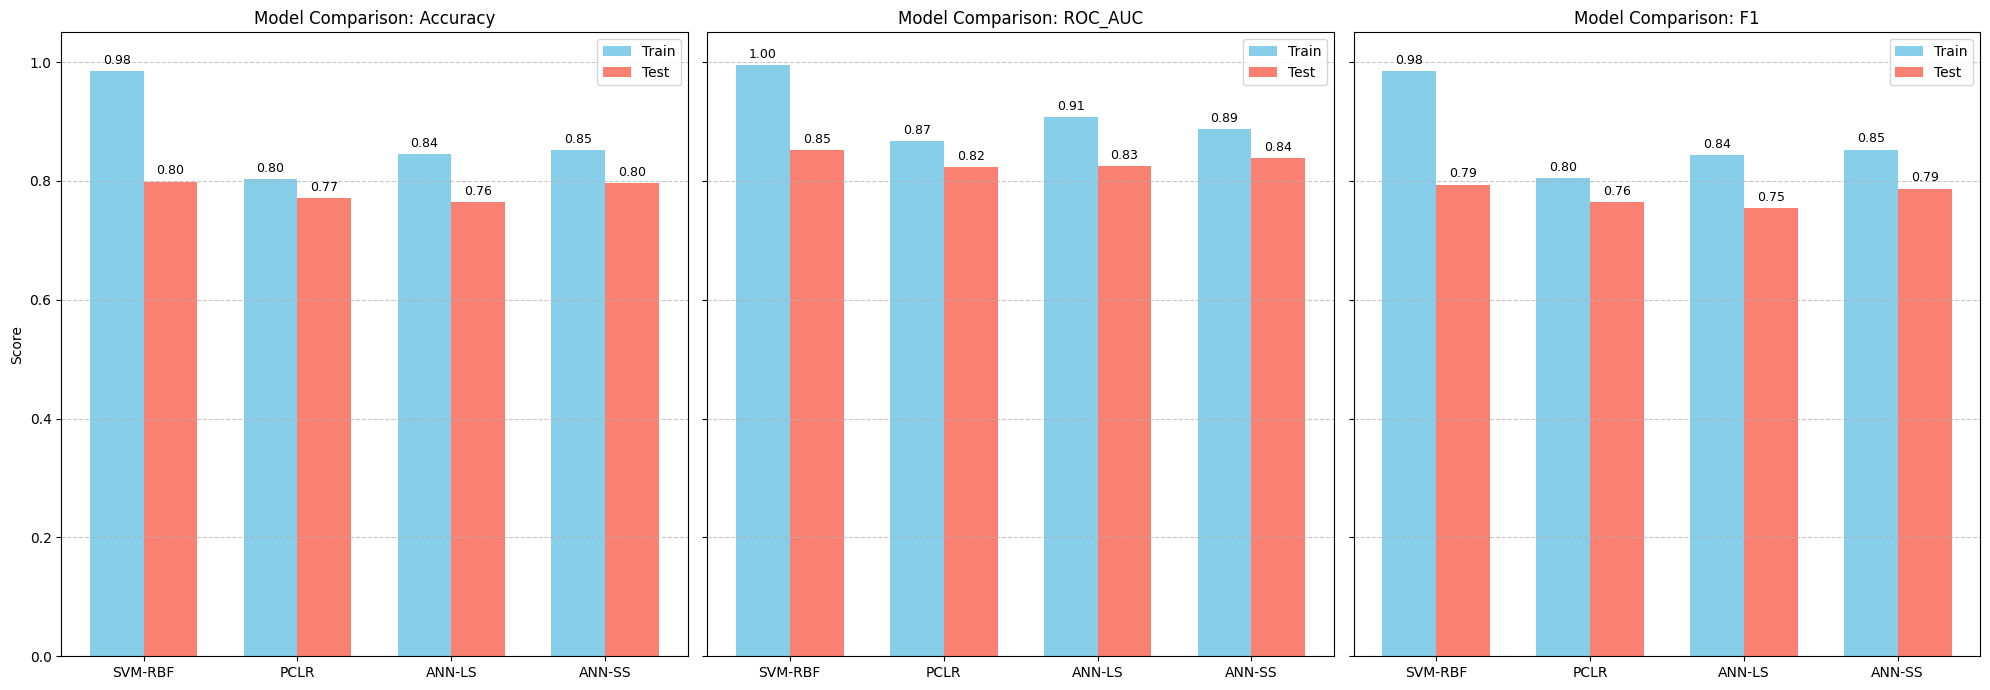

In [35]:
# Prepare data for plotting
labels = df_results['Model']
metrics = ['Accuracy', 'ROC_AUC', 'F1']

# Extract Train and Test scores
train_scores = df_results[['Train_Accuracy', 'Train_ROC_AUC', 'Train_F1']].values
test_scores = df_results[['Test_Accuracy', 'Test_ROC_AUC', 'Test_F1']].values

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)

for i, metric in enumerate(metrics):
    rects1 = axes[i].bar(x - width/2, train_scores[:, i], width, label='Train', color='skyblue')
    rects2 = axes[i].bar(x + width/2, test_scores[:, i], width, label='Test', color='salmon')

    # Add numerical labels to the bars
    axes[i].bar_label(rects1, padding=3, fmt='%.2f', fontsize=9)
    axes[i].bar_label(rects2, padding=3, fmt='%.2f', fontsize=9)

    axes[i].set_title(f'Model Comparison: {metric}')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(labels)
    axes[i].set_ylim(0, 1.05)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    if i == 0:
        axes[i].set_ylabel('Score')
    axes[i].legend(loc='upper right')

plt.tight_layout()
plt.show()

## 3.2 Confusion Matrices

To evaluate the prediction performance of each model more deeply, we visualize the Confusion Matrix for each classifier on the test set.

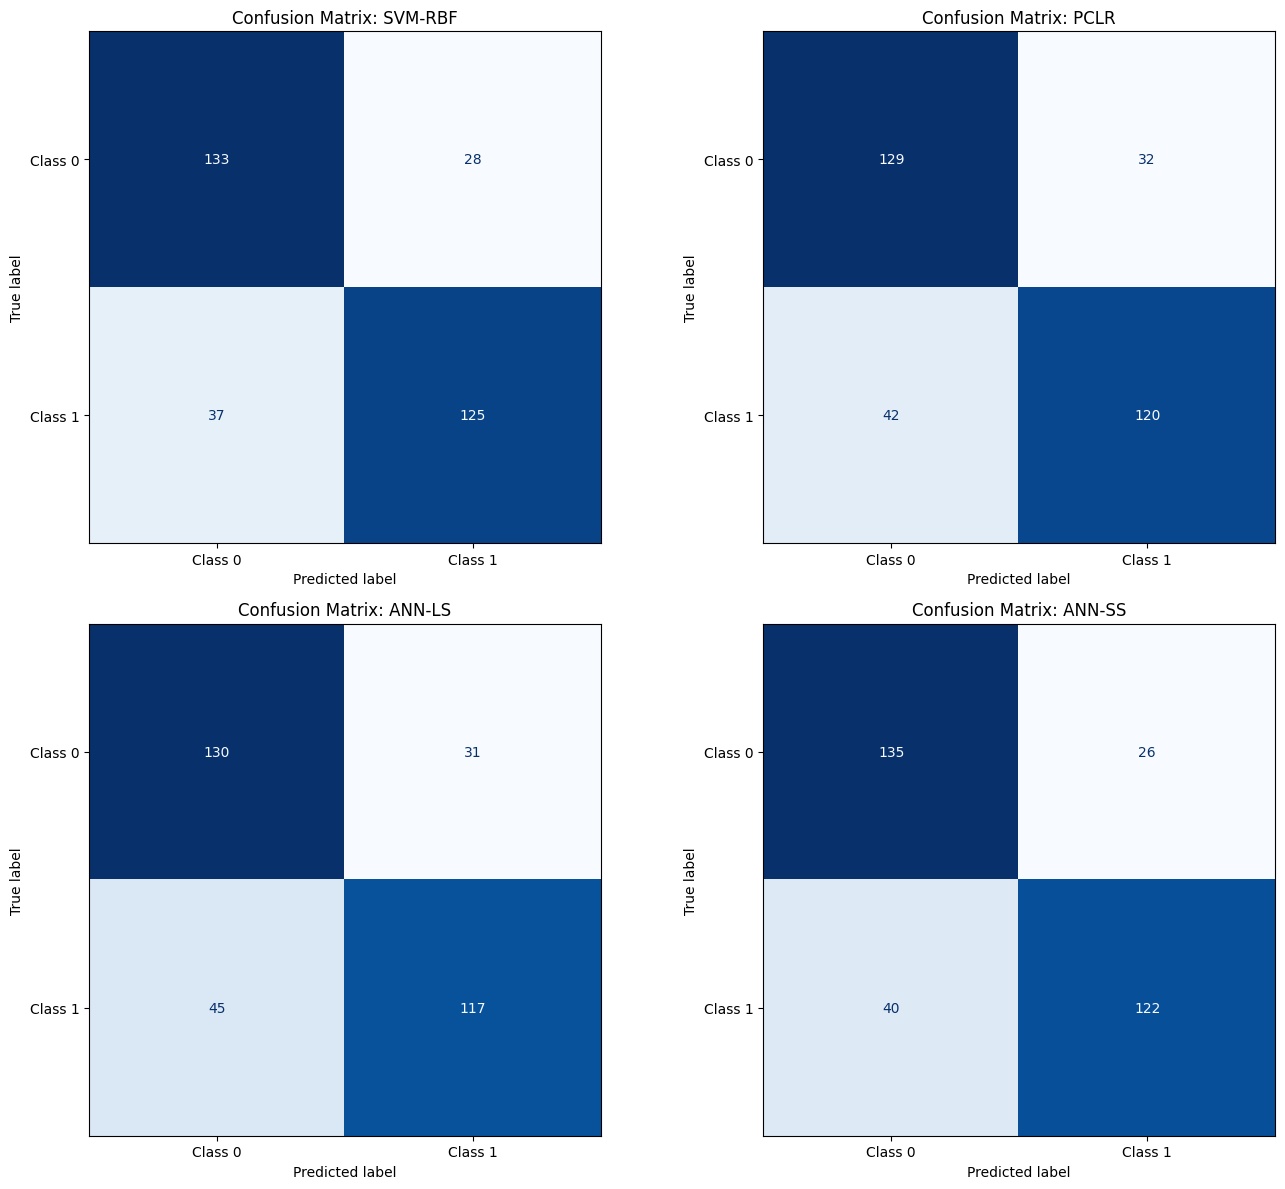

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for i, (name, model) in enumerate(models):
    # Get predictions
    y_pred = model.predict(X_test_knn)

    # Compute confusion matrix
    cm = confusion_matrix(YTest, y_pred)

    # Display confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'Confusion Matrix: {name}')

plt.tight_layout()
plt.show()